In [71]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [72]:
# ------------------- Paths -------------------
RUN_DIR = Path("./runs")
DATA_DIR = Path("/home/azureuser/NeuralHydrologyAzure/1_preparing_data/1_uy_basins_data/data/time_series")

In [73]:
run_patterns = {
    "CARAVAN": "precip_prcp_mm_day_seed_*",
    "CHIRPS":  "precip_prcp_chirps_mm_day_seed_*",
    "MSWEP":   "precip_prcp_mswep_mm_day_seed_*",
    "GAUGES":  "precip_prcp_gauge_mm_day_seed_*",
}

In [74]:
ensemble_by_pattern = {}

for label, pattern in run_patterns.items():
    matched_paths = sorted(RUN_DIR.glob(f"{pattern}/test/model_epoch030/test_results.p"))
    print(f"[{label}] Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")
    
    if not matched_paths:
        print(f"  WARNING: No runs found for '{label}', skipping.")
        continue
    
    all_runs_data = []
    for file_path in matched_paths:
        with open(file_path, "rb") as f:
            all_runs_data.append(pickle.load(f))
    
    ensemble_data = {}
    for basin_id in all_runs_data[0].keys():
        sims = np.stack([
            run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values
            for run in all_runs_data
        ], axis=0)
        
        mean_sim = np.mean(sims, axis=0)
        
        xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy(deep=True)
        xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim
        
        ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}
    
    ensemble_by_pattern[label] = ensemble_data

[CARAVAN] Found 8 runs: ['precip_prcp_mm_day_seed_111_2202_184533', 'precip_prcp_mm_day_seed_222_2202_185112', 'precip_prcp_mm_day_seed_333_2202_185649', 'precip_prcp_mm_day_seed_444_2202_190226', 'precip_prcp_mm_day_seed_555_2302_064058', 'precip_prcp_mm_day_seed_666_2302_064647', 'precip_prcp_mm_day_seed_777_2302_065235', 'precip_prcp_mm_day_seed_888_2302_065823']
[CHIRPS] Found 8 runs: ['precip_prcp_chirps_mm_day_seed_111_2904_071050', 'precip_prcp_chirps_mm_day_seed_222_2904_071648', 'precip_prcp_chirps_mm_day_seed_333_2904_072228', 'precip_prcp_chirps_mm_day_seed_444_2904_072803', 'precip_prcp_chirps_mm_day_seed_555_2904_073338', 'precip_prcp_chirps_mm_day_seed_666_2904_073913', 'precip_prcp_chirps_mm_day_seed_777_2904_074449', 'precip_prcp_chirps_mm_day_seed_888_2904_075024']
[MSWEP] Found 8 runs: ['precip_prcp_mswep_mm_day_seed_111_2804_222722', 'precip_prcp_mswep_mm_day_seed_222_2804_223324', 'precip_prcp_mswep_mm_day_seed_333_2804_223907', 'precip_prcp_mswep_mm_day_seed_444_28

In [75]:
ensemble_by_pattern

{'CARAVAN': {'CAMELS_UY_10': {'1D': {'xr': <xarray.Dataset> Size: 35kB
    Dimensions:        (date: 2191, time_step: 1)
    Coordinates:
      * date           (date) datetime64[ns] 18kB 2008-10-01 ... 2014-09-30
      * time_step      (time_step) int64 8B 0
    Data variables:
        QObs_mm_d_obs  (date, time_step) float32 9kB 0.2376 0.2216 ... 1.265 1.686
        QObs_mm_d_sim  (date, time_step) float32 9kB 0.4299 0.4396 ... 1.171 1.045}},
  'CAMELS_UY_11': {'1D': {'xr': <xarray.Dataset> Size: 35kB
    Dimensions:        (date: 2191, time_step: 1)
    Coordinates:
      * date           (date) datetime64[ns] 18kB 2008-10-01 ... 2014-09-30
      * time_step      (time_step) int64 8B 0
    Data variables:
        QObs_mm_d_obs  (date, time_step) float32 9kB 0.3589 0.3589 ... 0.8041 0.6947
        QObs_mm_d_sim  (date, time_step) float32 9kB 0.8108 0.7574 ... 0.6808 0.6359}},
  'CAMELS_UY_15': {'1D': {'xr': <xarray.Dataset> Size: 35kB
    Dimensions:        (date: 2191, time_step: 1)

In [76]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_basin_comparison(ensemble_by_pattern, basin_id, start_date=None, end_date=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = {"CARAVAN": "#1f77b4", "CHIRPS": "#ff7f0e", "MSWEP": "#2ca02c", "GAUGES": "#d62728"}
    
    first_label = next(iter(ensemble_by_pattern))
    xr_data = ensemble_by_pattern[first_label][basin_id]['1D']['xr']
    
    if start_date or end_date:
        xr_data = xr_data.sel(date=slice(start_date, end_date))
    
    dates = xr_data['date'].values
    obs = xr_data['QObs_mm_d_obs'].values[:, 0]
    ax.plot(dates, obs, color='black', linewidth=1.5, alpha=0.6, label='Observed', zorder=5)
    
    for label, ensemble_data in ensemble_by_pattern.items():
        xr_slice = ensemble_data[basin_id]['1D']['xr']
        if start_date or end_date:
            xr_slice = xr_slice.sel(date=slice(start_date, end_date))
        sim = xr_slice['QObs_mm_d_sim'].values[:, 0]
        ax.plot(dates, sim, color=colors[label], linewidth=1.5, alpha=0.7, label=label)
    
    ax.set_title(f"Simulated vs. observed streamflow", fontsize=16)

    ax.tick_params(axis='both', labelsize=16)

    ax.set_xlabel("Date", fontsize=15)
    ax.set_ylabel("Streamflow (mm/day)", fontsize=16)
    ax.legend(fontsize=16)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

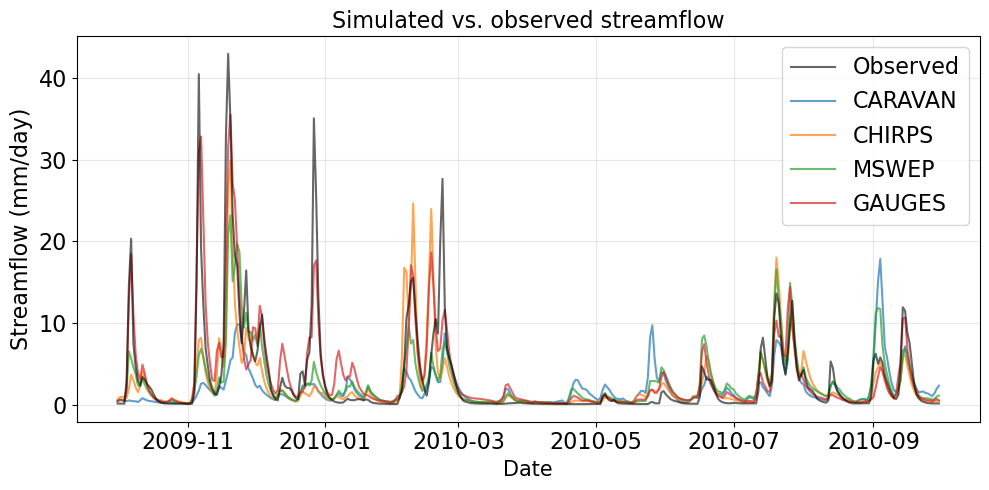

In [77]:
basin_ids = ["CAMELS_UY_8"]

# basin_ids = [
#     "CAMELS_UY_2", "CAMELS_UY_3", "CAMELS_UY_5", "CAMELS_UY_6",
#     "CAMELS_UY_7", "CAMELS_UY_8", "CAMELS_UY_9", "CAMELS_UY_10",
#     "CAMELS_UY_11", "CAMELS_UY_15", "CAMELS_UY_16"
# ]

# Usage
for basin_id in basin_ids:
    plot_basin_comparison(ensemble_by_pattern, basin_id, start_date="2009-10-01", end_date="2010-09-30")